# <b>1 <span style='color:#4285f4'>|</span> Setup</b>

## Importing Libraries
- **For ML Models**: sklearn  
- **For Data Processing**: numpy, pandas, sklearn  
- **For Data Visualization**: matplotlib, seaborn, plotly  

In [1]:
# For ML models
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC ,SVR
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# For Data Processing
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Miscellaneous
import os
import random

## Setting up sklearnex to speed up training
If you don't know about sklearnex, this is a tool you can use to speed up training sklearn models, without having to change any code.  
A simple 2 line of code can speed up training by 2x.  
You can follow [this notebook by Devlikamov Vlad](https://www.kaggle.com/code/lordozvlad/let-s-speed-up-your-kernels-using-sklearnex) to learn more about it

In [2]:
from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


# <b>2 <span style='color:#4285f4'>|</span> About the Dataset</b>

<h2>2.1 <span style='color:#4285f4'>|</span> Reading the data</h2>  

In [3]:
df = pd.read_csv('/kaggle/input/pima-indians-diabetes-database/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
fig = px.parallel_coordinates(df, color="Outcome",
                             color_continuous_scale=['#4285f4', '#ea4335'],
                             color_continuous_midpoint=0.5)
fig.show()

## Column descriptions
- `Pregnancies`: Number of times pregnant
- `Glucose`: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- `BloodPressure`: Diastolic blood pressure (mm Hg)
- `SkinThickness`: Triceps skin fold thickness (mm)
- `Insulin`: 2-Hour serum insulin (mu U/ml)
- `BMI`: Body mass index (weight in kg/(height in m)^2)
- `DiabetesPedigreeFunction`: Diabetes pedigree function
- `Age`: Age (years)
- `Outcome`: Class variable (0 or 1) 268 of 768 are 1, the others are 0

I am changing the column name `Outcome` to `Diabetes`, and replacing all the 1 and 0 in `Diabetes` column with `True` and `False`, for visualization purposes

In [5]:
df['Diabetes'] = df['Outcome']
del df['Outcome']
df['Diabetes'] = df['Diabetes'].apply(lambda x:{1:True, 0:False}[x])

<h2>2.3 <span style='color:#4285f4'>|</span> Column Statistics</h2>

In [6]:
df.describe()[1:].T.style.background_gradient(cmap='Blues')

,mean,std,min,25%,50%,75%,max
Pregnancies,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000


<h2>2.4 <span style='color:#4285f4'>|</span> Distribution of Diabetes</h2>

In [7]:
fig = go.Figure(data=[go.Pie(labels=df['Diabetes'].value_counts().index, values=df['Diabetes'].value_counts(), hole=.3)])
fig.update_layout(legend_title_text='Diabetes')
fig.show()

<h2>2.5 <span style='color:#4285f4'>|</span> Correlation Matrix</h2>

In [8]:
fig = px.imshow(df.corr(),color_continuous_scale="Blues")
fig.update_layout(height=620)
fig.show()

<h2>2.6 <span style='color:#4285f4'>|</span> Distribution of Correlation of features</h2>

In [9]:
df_corr_bar = abs(df.corr()['Diabetes']).sort_values()[:-1]
fig = px.bar(df_corr_bar, orientation='h', color_discrete_sequence =['#4285f4']*len(df_corr_bar))
fig.update_layout(showlegend=False)
fig.show()

# <b>3 <span style='color:#4285f4'>|</span> Exploratory Analysis</b>

<h2>3.1 <span style='color:#4285f4'>|</span> Bivariate Analysis</h2>

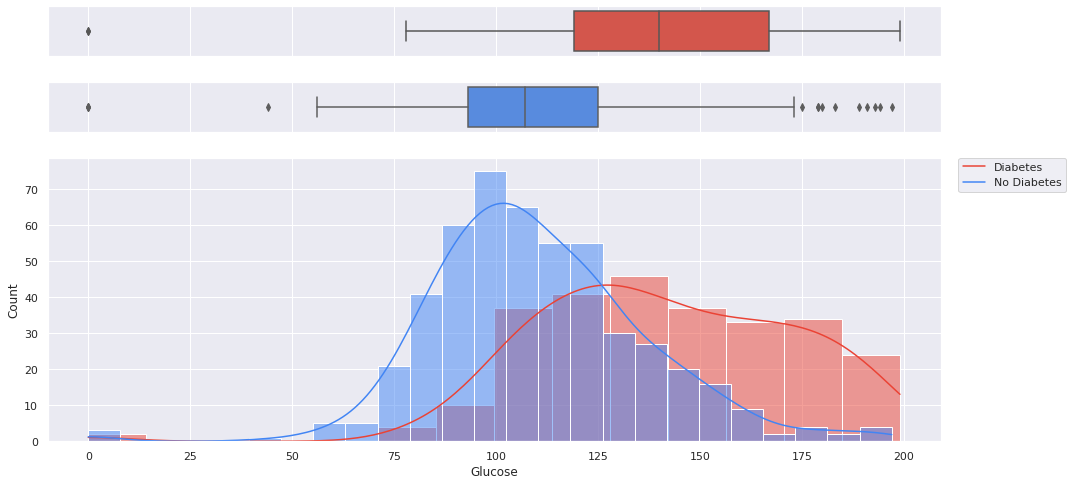

In [10]:
sns.set(style="darkgrid")
sns.set(rc={'figure.figsize':(16,8)})
 
# creating a figure composed of 3 matplotlib.Axes objects
f, (ax_box1, ax_box2, ax_hist) = plt.subplots(3, sharex=True, gridspec_kw={"height_ratios": (.15, .15, .85)})
colours = ['#4285f4', '#ea4335', '#fbbc05', '#34a853']
# assigning a graph to each ax
sns.boxplot(x=df[df['Diabetes']==True]["Glucose"], ax=ax_box1, color="#ea4335")
sns.histplot(df[df['Diabetes']==True], x="Glucose", ax=ax_hist, kde=True, color="#ea4335")

sns.boxplot(x=df[df['Diabetes']==False]["Glucose"], ax=ax_box2, color='#4285f4')
sns.histplot(df[df['Diabetes']==False], x="Glucose", ax=ax_hist, kde=True, color='#4285f4')
 
# Remove x axis name for the boxplots
ax_box1.set(xlabel='')
ax_box2.set(xlabel='')

plt.legend(title='', loc=2, labels=['Diabetes', 'No Diabetes'],bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.show()

### Insights
- `Glucose` has a correlation value of 0.467
- A higher glucose level usually mean a higher chance of diabetes

<AxesSubplot:xlabel='SkinThickness', ylabel='BMI'>

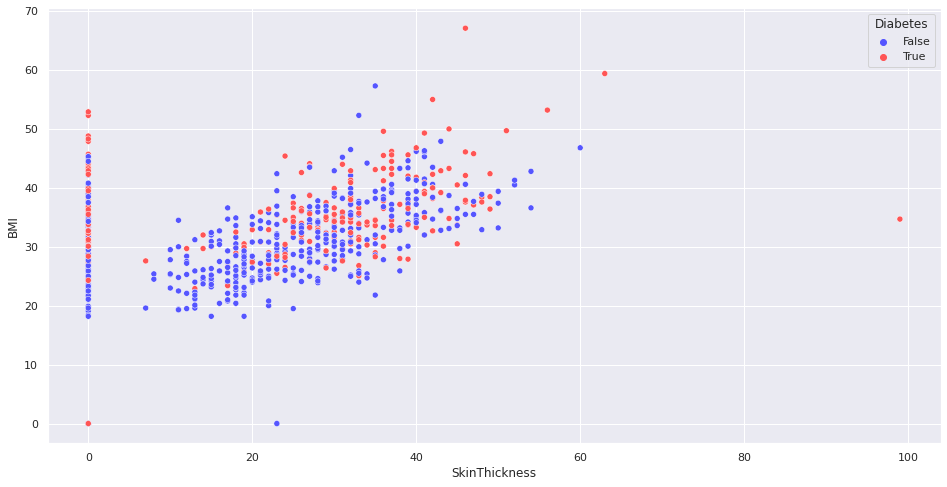

In [11]:
sns.scatterplot(data=df, x="SkinThickness", y="BMI", hue="Diabetes", palette='seismic')

### Insights
- SkinThickness and BMI have a correlation value of 0.393
- A high SkinThickness usually means a higher BMI
- A high BMI means a higher chance of Diabetes (this is seen more clearly in the BMI-Diabetes Histogram-Boxplot below)

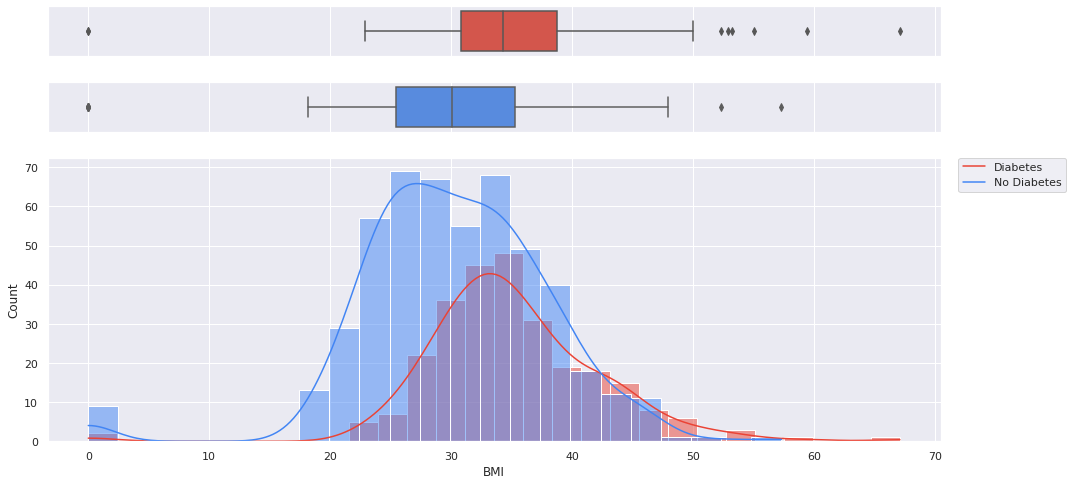

In [12]:
sns.set(style="darkgrid")
sns.set(rc={'figure.figsize':(16,8)})
 
# creating a figure composed of 3 matplotlib.Axes objects
f, (ax_box1, ax_box2, ax_hist) = plt.subplots(3, sharex=True, gridspec_kw={"height_ratios": (.15, .15, .85)})
colours = ['#4285f4', '#ea4335', '#fbbc05', '#34a853']
# assigning a graph to each ax
sns.boxplot(x=df[df['Diabetes']==True]["BMI"], ax=ax_box1, color="#ea4335")
sns.histplot(df[df['Diabetes']==True], x="BMI", ax=ax_hist, kde=True, color="#ea4335")

sns.boxplot(x=df[df['Diabetes']==False]["BMI"], ax=ax_box2, color='#4285f4')
sns.histplot(df[df['Diabetes']==False], x="BMI", ax=ax_hist, kde=True, color='#4285f4')
 
# Remove x axis name for the boxplots
ax_box1.set(xlabel='')
ax_box2.set(xlabel='')

plt.legend(title='', loc=2, labels=['Diabetes', 'No Diabetes'],bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.show()

### Insights
- BMI and Diabetes have a correlation value of 0.293
- A higher BMI usually means a higher chance of Diabetes

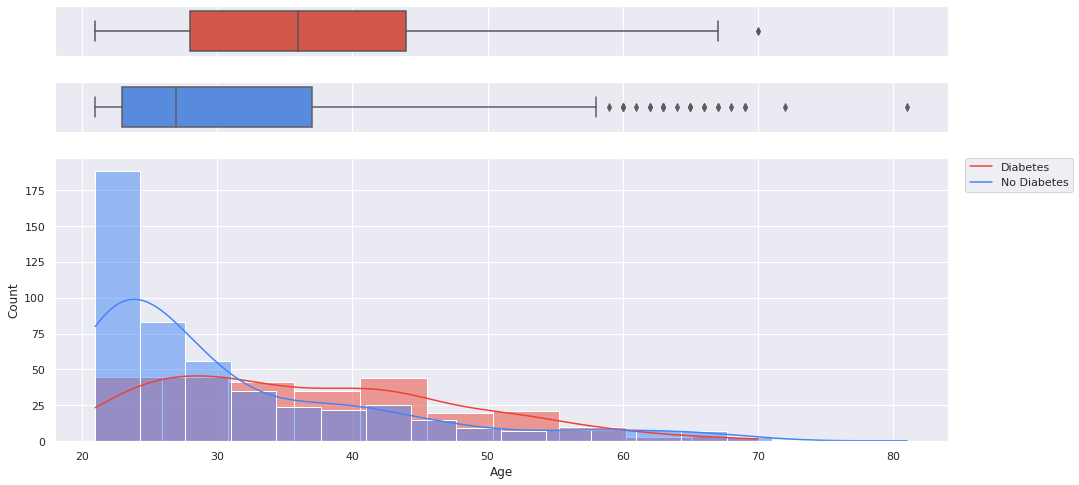

In [13]:
sns.set(style="darkgrid")
sns.set(rc={'figure.figsize':(16,8)})
 
# creating a figure composed of 3 matplotlib.Axes objects
f, (ax_box1, ax_box2, ax_hist) = plt.subplots(3, sharex=True, gridspec_kw={"height_ratios": (.15, .15, .85)})
colours = ['#4285f4', '#ea4335', '#fbbc05', '#34a853']
# assigning a graph to each ax
sns.boxplot(x=df[df['Diabetes']==True]["Age"], ax=ax_box1, color="#ea4335")
sns.histplot(df[df['Diabetes']==True], x="Age", ax=ax_hist, kde=True, color="#ea4335")

sns.boxplot(x=df[df['Diabetes']==False]["Age"], ax=ax_box2, color='#4285f4')
sns.histplot(df[df['Diabetes']==False], x="Age", ax=ax_hist, kde=True, color='#4285f4')
 
# Remove x axis name for the boxplots
ax_box1.set(xlabel='')
ax_box2.set(xlabel='')

plt.legend(title='', loc=2, labels=['Diabetes', 'No Diabetes'],bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.show()

### Insights
- Age and Diabetes has a correlation value of 0.238
- A higher age usually means a higher chance of diabetes

<h2>3.2 <span style='color:#4285f4'>|</span> EDA Conclusion</h2>

- A higher glucose level usually mean a higher chance of diabetes  
- A high SkinThickness usually means a higher BMI  
- A high BMI means a higher chance of Diabetes  
- A high age usually means a high chance of diabetes

# <b>4 <span style='color:#4285f4'>|</span> Data Preprocessing</b>

<h2>Preparing Training and Validation arrays</h2>  

Here I am creating arrays for features and labels.  
And splitting the dataset:
- 20% for validation
- 80% for training

In [14]:
features = np.array(df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction']])
labels = np.array(df['Diabetes'])

x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=0)

# <b>5 <span style='color:#4285f4'>|</span> Models</b>

In [15]:
model_comparison = {} # To store performance of each model

<h2>5.1 <span style='color:#4285f4'>|</span> SVC</h2>  

In [16]:
parameters = {'C': [2,3,4,5], 'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}

svc_model = SVC()

clf = GridSearchCV(svc_model, parameters)
print("Searching for best hyperparameters ...")
clf.fit(x_train, y_train)
print(f'Best Hyperparameters: {clf.best_params_}')

y_pred = clf.predict(x_val)
model_comparison['SVC'] = [accuracy_score(y_val,y_pred), f1_score(y_val,y_pred, average='weighted')]
print('\n')
print(classification_report(y_val,y_pred, zero_division=1))

Searching for best hyperparameters ...
Best Hyperparameters: {'C': 4, 'kernel': 'rbf'}


              precision    recall  f1-score   support

       False       0.82      0.91      0.86       107
        True       0.72      0.55      0.63        47

    accuracy                           0.80       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.79      0.80      0.79       154



<h2>5.2 <span style='color:#4285f4'>|</span> DecisionTreeClassifier</h2>  

In [17]:
parameters = {'max_depth': [1,2,3,4,5,6]}

Tree_model = DecisionTreeClassifier()

clf = GridSearchCV(Tree_model, parameters)
print("Searching for best hyperparameters ...")
clf.fit(x_train, y_train)
print(f'Best Hyperparameters: {clf.best_params_}')

y_pred = clf.predict(x_val)
model_comparison['DecisionTreeClassifier'] = [accuracy_score(y_val,y_pred), f1_score(y_val,y_pred, average='weighted')]
print('\n')
print(classification_report(y_val,y_pred, zero_division=1))

Searching for best hyperparameters ...
Best Hyperparameters: {'max_depth': 2}


              precision    recall  f1-score   support

       False       0.80      0.87      0.83       107
        True       0.63      0.51      0.56        47

    accuracy                           0.76       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.75      0.76      0.75       154



<h2>5.3 <span style='color:#4285f4'>|</span> KNeighborsClassifier</h2>  

In [18]:
parameters = {'n_neighbors': [20,30,40,50]}

K_model = KNeighborsClassifier()

clf = GridSearchCV(K_model, parameters)
print("Searching for best hyperparameters ...")
clf.fit(x_train, y_train)
print(f'Best Hyperparameters: {clf.best_params_}')

y_pred = clf.predict(x_val)
model_comparison['KNeighborsClassifier'] = [accuracy_score(y_val,y_pred), f1_score(y_val,y_pred, average='weighted')]
print('\n')
print(classification_report(y_val,y_pred, zero_division=1))

Searching for best hyperparameters ...
Best Hyperparameters: {'n_neighbors': 30}


              precision    recall  f1-score   support

       False       0.80      0.92      0.85       107
        True       0.71      0.47      0.56        47

    accuracy                           0.78       154
   macro avg       0.75      0.69      0.71       154
weighted avg       0.77      0.78      0.76       154



<h2>5.4 <span style='color:#4285f4'>|</span> RandomForestClassifier</h2>  

In [19]:
parameters = {'n_estimators': [160,180,200], 'max_depth':[18,20,22]}

rf = RandomForestClassifier()

clf = GridSearchCV(rf, parameters)
print("Searching for best hyperparameters ...")
clf.fit(x_train, y_train)
print(f'Best Hyperparameters: {clf.best_params_}')

y_pred = clf.predict(x_val)
model_comparison['RandomForestClassifier'] = [accuracy_score(y_val,y_pred), f1_score(y_val,y_pred, average='weighted')]
print('\n')
print(classification_report(y_val,y_pred, zero_division=1))

Searching for best hyperparameters ...
Best Hyperparameters: {'max_depth': 18, 'n_estimators': 180}


              precision    recall  f1-score   support

       False       0.85      0.87      0.86       107
        True       0.68      0.64      0.66        47

    accuracy                           0.80       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.80      0.80      0.80       154



<h2>5.5 <span style='color:#4285f4'>|</span> XGBoost</h2>  

In [20]:
parameters = {'n_estimators': [100, 150, 200], 'max_depth':[18, 20, 22]}

xgboost = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

clf = GridSearchCV(xgboost, parameters)
print("Searching for best hyperparameters ...")
clf.fit(x_train, y_train)
print(f'Best Hyperparameters: {clf.best_params_}')

y_pred = clf.predict(x_val)
model_comparison['XGBoost'] = [accuracy_score(y_val, y_pred), f1_score(y_val,y_pred, average='weighted')]
print('\n')
print(classification_report(y_val,y_pred, zero_division=1))

Searching for best hyperparameters ...
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 150}


              precision    recall  f1-score   support

       False       0.84      0.84      0.84       107
        True       0.64      0.64      0.64        47

    accuracy                           0.78       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.78      0.78      0.78       154



<h2>5.6 <span style='color:#4285f4'>|</span> Model Comparison</h2>  

In [21]:
model_comparison_df = pd.DataFrame.from_dict(model_comparison).T
model_comparison_df.columns = ['Accuracy', 'F1 Score']
model_comparison_df = model_comparison_df.sort_values('F1 Score', ascending=True)
model_comparison_df.style.background_gradient(cmap='Blues')

,Accuracy,F1 Score
DecisionTreeClassifier,0.759740,0.751869
KNeighborsClassifier,0.779221,0.764256
XGBoost,0.779221,0.779221
SVC,0.798701,0.790283
RandomForestClassifier,0.798701,0.796775


In [22]:
fig = go.Figure(data=[
    go.Bar(name='F1 Score', y=model_comparison_df.index, x=model_comparison_df['F1 Score'], orientation='h', marker_color='#7baaf7'),
    go.Bar(name='Accuracy', y=model_comparison_df.index, x=model_comparison_df['Accuracy'], orientation='h', marker_color='#4285f4')
])
fig.update_layout(barmode='group')
fig.show()

***
hi
***